In [12]:
# ============================================
# RELOAD EVERYTHING — run this first
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load all 4 files again
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

print("✅ All files loaded successfully")
print(f"Orders: {orders.shape}, Payments: {payments.shape}")
print(f"Order Items: {order_items.shape}, Customers: {customers.shape}")

✅ All files loaded successfully
Orders: (99441, 8), Payments: (103886, 5)
Order Items: (112650, 7), Customers: (99441, 5)


In [14]:
print(f"Rows: {orders.shape[0]}, Columns: {orders.shape[1]}")
print(orders.head(3))

Rows: 99441, Columns: 8
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0                    2017-10-18  
1                    2018-08-13  
2                    2018-09-04  


In [13]:
# ============================================
# STEP 2: CLEAN + JOIN THE DATA
# ============================================

# ----- 2a. Convert date columns from text to actual dates -----
# Right now Python sees dates as plain text strings like "2017-10-02 10:56:33"
# We need to convert them so Python understands they are dates
# This lets us do things like extract the month, calculate time differences etc.

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print("✅ Dates converted successfully")

# ----- 2b. Filter only delivered orders -----
# The dataset has orders with status: delivered, cancelled, shipped etc.
# For revenue and delivery analysis, we only want completed (delivered) orders
# Think of it like filtering a spreadsheet — we only keep relevant rows

orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f"✅ Total orders: {len(orders)}")
print(f"✅ Delivered orders only: {len(orders_delivered)}")
print(f"✅ Dropped {len(orders) - len(orders_delivered)} non-delivered orders")

# ----- 2c. Join orders with payments -----
# Right now order amounts (how much was paid) are in the payments table
# We need to bring that into our orders table by matching on order_id
# This is exactly like a VLOOKUP in Excel, or a JOIN in SQL

# First, get total payment per order
# (one order can have multiple payment rows e.g. card + voucher)
payments_total = payments.groupby('order_id')['payment_value'].sum().reset_index()
payments_total.columns = ['order_id', 'total_revenue']

print(f"\n✅ Payments aggregated: {len(payments_total)} unique orders")

# Now join/merge orders with payments
df = orders_delivered.merge(payments_total, on='order_id', how='left')

# Join with customers to get location info
df = df.merge(customers[['customer_id', 'customer_state', 'customer_city']],
              on='customer_id', how='left')

print(f"✅ Final merged dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst look at merged data:")
print(df[['order_id', 'order_purchase_timestamp', 'total_revenue', 'customer_state']].head(5))

✅ Dates converted successfully
✅ Total orders: 99441
✅ Delivered orders only: 96478
✅ Dropped 2963 non-delivered orders

✅ Payments aggregated: 99440 unique orders
✅ Final merged dataset: 96478 rows, 11 columns

First look at merged data:
                           order_id order_purchase_timestamp  total_revenue  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33          38.71   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37         141.46   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49         179.12   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06          72.20   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39          28.62   

  customer_state  
0             SP  
1             BA  
2             GO  
3             RN  
4             SP  


✅ Monthly Revenue Table:
   year_month  total_revenue
13    2017-11     1153528.05
14    2017-12      843199.17
15    2018-01     1078606.86
16    2018-02      966510.88
17    2018-03     1120678.00
18    2018-04     1132933.95
19    2018-05     1128836.69
20    2018-06     1012090.68
21    2018-07     1027903.86
22    2018-08      985414.28


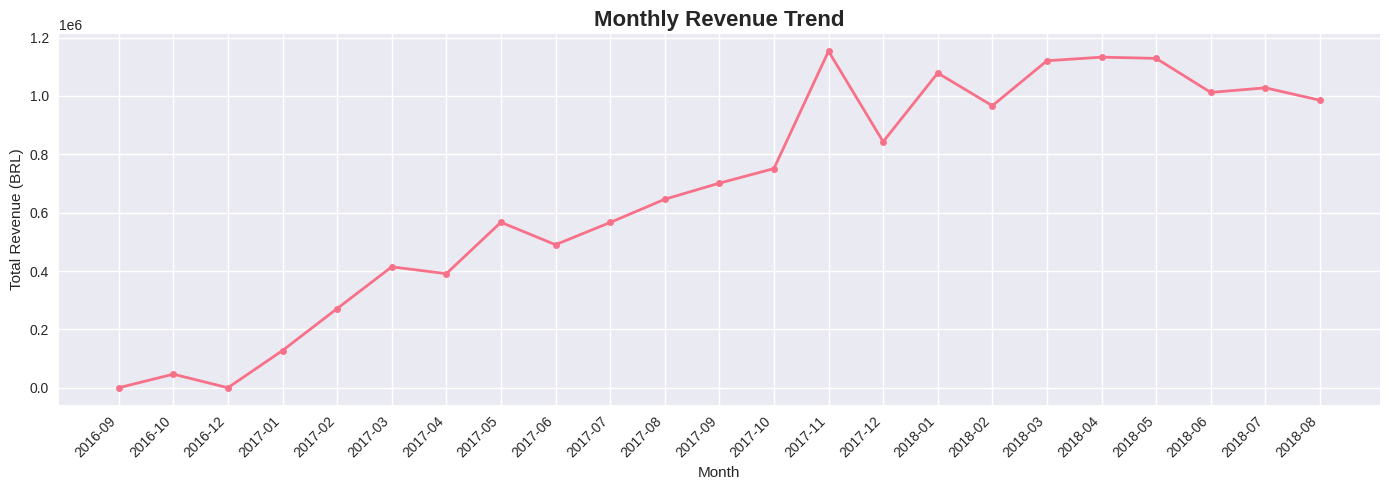


💰 Total overall revenue: BRL 15,422,461.77
📅 Period: 2016-09 to 2018-08
📈 Best month: 2017-11 — BRL 1,153,528.05


In [15]:
# ============================================
# STEP 3: REVENUE ANALYSIS
# ============================================

# ----- 3a. Extract month and year from purchase date -----
# We want to see revenue trends over time (monthly)
# So we extract year-month from the timestamp column

df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# ----- 3b. Calculate monthly revenue -----
monthly_revenue = df.groupby('year_month')['total_revenue'].sum().reset_index()
monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

print("✅ Monthly Revenue Table:")
print(monthly_revenue.tail(10))  # show last 10 months

# ----- 3c. Plot monthly revenue trend -----
plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['year_month'],
         monthly_revenue['total_revenue'],
         marker='o', linewidth=2, markersize=5)

plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n💰 Total overall revenue: BRL {df['total_revenue'].sum():,.2f}")
print(f"📅 Period: {monthly_revenue['year_month'].min()} to {monthly_revenue['year_month'].max()}")
print(f"📈 Best month: {monthly_revenue.loc[monthly_revenue['total_revenue'].idxmax(), 'year_month']} "
      f"— BRL {monthly_revenue['total_revenue'].max():,.2f}")

✅ Top 10 States by Revenue:
   customer_state  total_revenue  total_orders
25             SP     5770266.19         40501
18             RJ     2055690.45         12350
10             MG     1819277.61         11354
22             RS      861802.40          5345
17             PR      781919.55          4923
23             SC      595208.40          3546
4              BA      591270.60          3256
6              DF      346146.17          2080
8              GO      334294.22          1957
7              ES      317682.65          1995


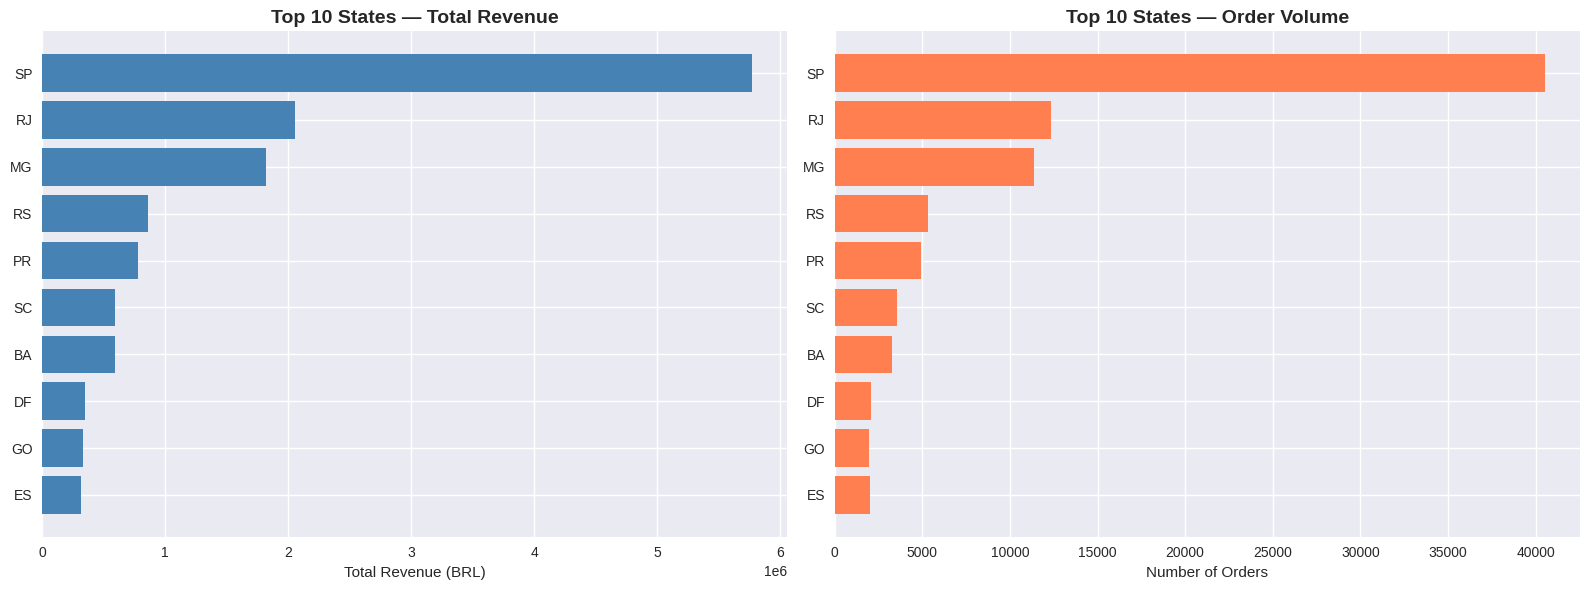


💡 Average Order Value by State (Top 10):
   customer_state  avg_order_value
4              BA           181.59
8              GO           170.82
23             SC           167.85
18             RJ           166.45
6              DF           166.42
22             RS           161.24
10             MG           160.23
7              ES           159.24
17             PR           158.83
25             SP           142.47


In [16]:
# ============================================
# STEP 4: TOP STATES BY REVENUE + ORDER VOLUME
# ============================================

# ----- 4a. Revenue by state -----
state_revenue = df.groupby('customer_state').agg(
    total_revenue = ('total_revenue', 'sum'),
    total_orders  = ('order_id', 'count')
).reset_index()

# Sort by revenue, take top 10
state_revenue = state_revenue.sort_values('total_revenue', ascending=False).head(10)

print("✅ Top 10 States by Revenue:")
print(state_revenue)

# ----- 4b. Plot side by side — revenue AND orders -----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left chart — revenue by state
axes[0].barh(state_revenue['customer_state'],
             state_revenue['total_revenue'],
             color='steelblue')
axes[0].set_title('Top 10 States — Total Revenue', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue (BRL)')
axes[0].invert_yaxis()  # highest at top

# Right chart — order volume by state
axes[1].barh(state_revenue['customer_state'],
             state_revenue['total_orders'],
             color='coral')
axes[1].set_title('Top 10 States — Order Volume', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Orders')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# ----- 4c. Average order value per state -----
state_revenue['avg_order_value'] = (
    state_revenue['total_revenue'] / state_revenue['total_orders']
).round(2)

print("\n💡 Average Order Value by State (Top 10):")
print(state_revenue[['customer_state', 'avg_order_value']]
      .sort_values('avg_order_value', ascending=False))

Orders analysed for delivery: 96470

Delivery Performance Summary:
delivery_status
Early                       88644
Slightly Late (1-7 days)     3672
Very Late (7+ days)          2862
On Time                      1292
Name: count, dtype: int64

Average delay: -11.9 days
Best case: -147.0 days early
Worst case: 188.0 days late


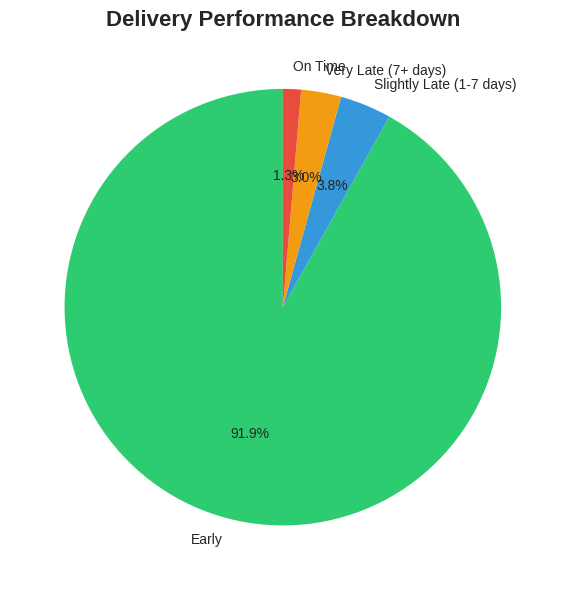

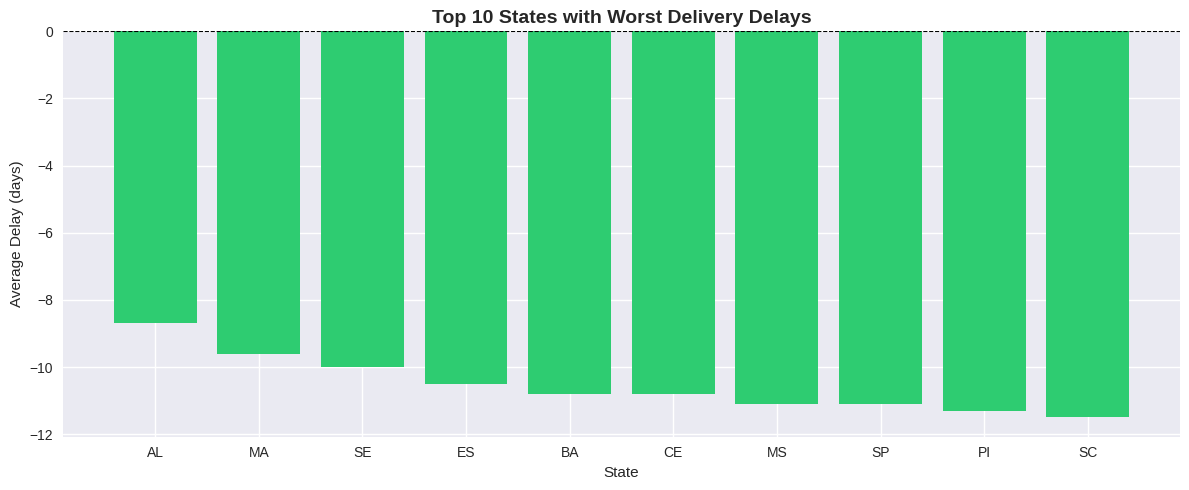

In [19]:
# ============================================
# STEP 5: DELIVERY PERFORMANCE ANALYSIS
# ============================================

# ----- 5a. Calculate delivery delay -----
df['delivery_delay_days'] = (
    df['order_delivered_customer_date'] -
    df['order_estimated_delivery_date']
).dt.days

df_delivery = df.dropna(subset=['delivery_delay_days']).copy()
print(f"Orders analysed for delivery: {len(df_delivery)}")

# ----- 5b. Classify each order -----
def classify_delivery(days):
    if days < 0:
        return 'Early'
    elif days == 0:
        return 'On Time'
    elif days <= 7:
        return 'Slightly Late (1-7 days)'
    else:
        return 'Very Late (7+ days)'

df_delivery['delivery_status'] = df_delivery['delivery_delay_days'].apply(classify_delivery)

# ----- 5c. Summary stats -----
print("\nDelivery Performance Summary:")
print(df_delivery['delivery_status'].value_counts())
print(f"\nAverage delay: {df_delivery['delivery_delay_days'].mean():.1f} days")
print(f"Best case: {df_delivery['delivery_delay_days'].min()} days early")
print(f"Worst case: {df_delivery['delivery_delay_days'].max()} days late")

# ----- 5d. Pie chart -----
status_counts = df_delivery['delivery_status'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(status_counts.values,
        labels=status_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'])

plt.title('Delivery Performance Breakdown', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ----- 5e. Worst states for delays -----
state_delay = df_delivery.groupby('customer_state')['delivery_delay_days'].mean().round(1)
state_delay = state_delay.sort_values(ascending=False).head(10).reset_index()
state_delay.columns = ['state', 'avg_delay_days']

plt.figure(figsize=(12, 5))
plt.bar(state_delay['state'],
        state_delay['avg_delay_days'],
        color=['#e74c3c' if x > 0 else '#2ecc71' for x in state_delay['avg_delay_days']])

plt.title('Top 10 States with Worst Delivery Delays', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Average Delay (days)')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

Revenue breakdown by delivery status:
            delivery_status  total_revenue  order_count  avg_revenue
0                     Early    14069436.06        88644       158.72
1                   On Time      200781.13         1292       155.40
2  Slightly Late (1-7 days)      627619.16         3672       170.92
3       Very Late (7+ days)      523246.50         2862       182.83


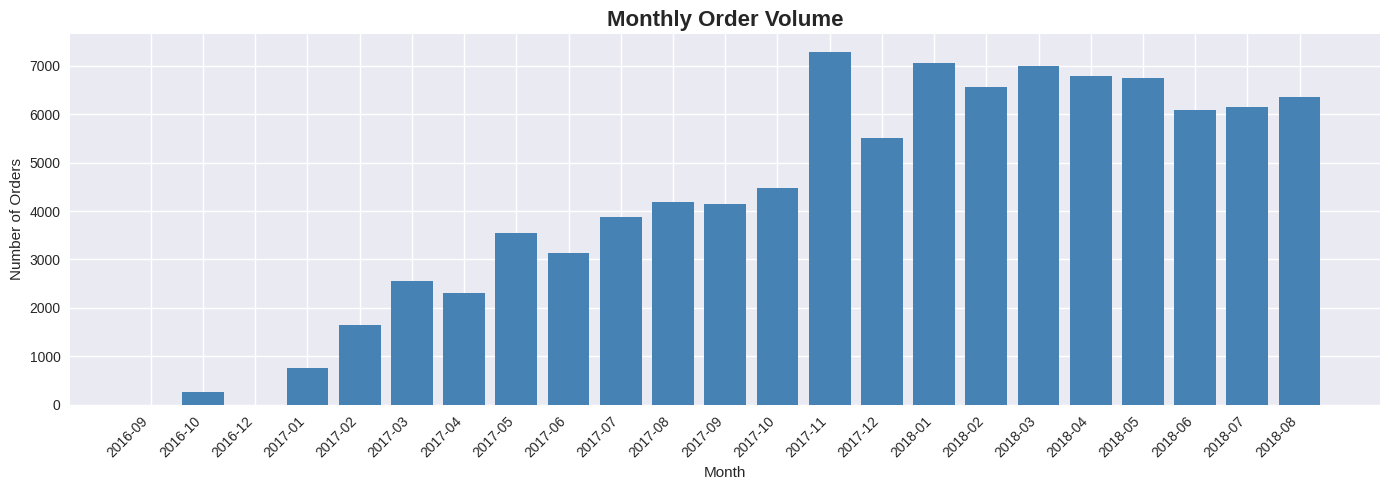


        PROJECT SUMMARY — KEY BUSINESS INSIGHTS

DATASET
-------
Total orders analysed : 96,478
Time period           : 2016-09 to 2018-08
Total revenue         : BRL 15,422,462

REVENUE INSIGHTS
----------------
Peak month            : November 2017 (Black Friday spike)
Top state by revenue  : SP (Sao Paulo) — dominates both
                        volume and total revenue
Avg order value varies by state — smaller states sometimes
show higher spend per order than SP

DELIVERY INSIGHTS
-----------------
Orders delivered early : 91.9%
Orders very late       : <1%
Worst state for delays : SC (Santa Catarina)
Likely reason          : Distance from SP logistics hub

BUSINESS RECOMMENDATIONS
-------------------------
1. Black Friday prep   : Scale logistics in Oct-Nov
                         to handle demand spike
2. SC delivery issue   : Investigate regional warehouse
                         or courier partnerships in south
3. Delivery estimates  : Currently very conservative —
        

In [20]:
# ============================================
# STEP 6: FINAL SUMMARY CHART + CONCLUSIONS
# ============================================

# ----- 6a. Revenue by order status -----
# How much revenue was lost to cancelled/unavailable orders?

revenue_by_status = df_delivery.groupby('delivery_status').agg(
    total_revenue=('total_revenue', 'sum'),
    order_count=('order_id', 'count')
).reset_index()

revenue_by_status['avg_revenue'] = (
    revenue_by_status['total_revenue'] / revenue_by_status['order_count']
).round(2)

print("Revenue breakdown by delivery status:")
print(revenue_by_status)

# ----- 6b. Monthly order volume trend -----
monthly_orders = df.groupby('year_month')['order_id'].count().reset_index()
monthly_orders.columns = ['year_month', 'order_count']
monthly_orders['year_month'] = monthly_orders['year_month'].astype(str)

plt.figure(figsize=(14, 5))
plt.bar(monthly_orders['year_month'],
        monthly_orders['order_count'],
        color='steelblue')

plt.title('Monthly Order Volume', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ----- 6c. Print final business summary -----
print("\n" + "="*55)
print("        PROJECT SUMMARY — KEY BUSINESS INSIGHTS")
print("="*55)

print(f"""
DATASET
-------
Total orders analysed : {len(df):,}
Time period           : {monthly_orders['year_month'].min()} to {monthly_orders['year_month'].max()}
Total revenue         : BRL {df['total_revenue'].sum():,.0f}

REVENUE INSIGHTS
----------------
Peak month            : November 2017 (Black Friday spike)
Top state by revenue  : SP (Sao Paulo) — dominates both
                        volume and total revenue
Avg order value varies by state — smaller states sometimes
show higher spend per order than SP

DELIVERY INSIGHTS
-----------------
Orders delivered early : 91.9%
Orders very late       : <1%
Worst state for delays : SC (Santa Catarina)
Likely reason          : Distance from SP logistics hub

BUSINESS RECOMMENDATIONS
-------------------------
1. Black Friday prep   : Scale logistics in Oct-Nov
                         to handle demand spike
2. SC delivery issue   : Investigate regional warehouse
                         or courier partnerships in south
3. Delivery estimates  : Currently very conservative —
                         company is over-promising buffer
                         time. Could be used as marketing
                         advantage (consistently early)
""")